# Day 01: 卷积的诞生 —— 让机器学会「看」图

> 👁️ 第三周 · 视觉的征服与深度的瓶颈 · 第 1 天

当你看到一只猫时，无论它出现在图片的左上角、右下角，还是中间，你的大脑都能立刻认出它。

但对于传统神经网络来说，图片里猫的位置稍有变化，整个识别结果就可能崩溃。

这是为什么？问题出在「全连接层」处理图片的方式上。今天我们将学习一项颠覆性的技术——**卷积神经网络（CNN）**，以及它的核心运算：**卷积**。

**今日任务**：理解卷积运算的本质，用一个 3x3 边缘检测卷积核亲手「提取」图片边缘。

---

## 1. 全连接层的致命缺陷

想象一下，你要把一张 100x100 像素的彩色图片（3万 个像素 × 3个通道 = 30万 个输入）输入神经网络。

如果第一层有 1000 个神经元，那这一层的参数数量是：
```
30万 × 1000 = 3亿 个参数！
```
这就是「参数量爆炸」问题。而且，图片平移一点，30万个数字全部变化，网络就必须重新学习。

类比：全连接层就像一个「记忆超人」，试图记住图片里每一个像素的精确位置。

但人类视觉是怎么工作的？你并不「记住」猫在每个像素的位置，而是提取「有没有尖耳朵」「有没有胡须」这样的**特征**。

In [1]:
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

import torch
import matplotlib.pyplot as plt
import numpy as np

# 模拟一张简单的「图片」：黑白渐变
# 想象这是照片的一小部分
image = torch.tensor([
    [0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 1.0, 1.0, 0.0],  # 白色方块（从上到下渐变）
    [0.0, 1.0, 1.0, 1.0, 0.0],
    [0.0, 1.0, 1.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0]
], dtype=torch.float32)

print("一张简单的「图片」：")
print(image)
print(f"\n图片尺寸: {image.shape}")
print("\n想象这是画面中的一道边缘——左边是背景（暗），右边是物体（亮）")

一张简单的「图片」：
tensor([[0., 0., 0., 0., 0.],
        [0., 1., 1., 1., 0.],
        [0., 1., 1., 1., 0.],
        [0., 1., 1., 1., 0.],
        [0., 0., 0., 0., 0.]])

图片尺寸: torch.Size([5, 5])

想象这是画面中的一道边缘——左边是背景（暗），右边是物体（亮）


---

## 2. 卷积：一种「滑动窗口」运算

卷积的核心思想是：**用一个滑动的小窗口（卷积核）扫过整张图片，在每个位置做一次「局部对话」**。

类比：想象你用手指在一张纸上滑动：
- 手指 = 卷积核（Kernel）
- 每次触摸到的区域 = 局部感受野（Local Receptive Field）
- 你感受到的「是冷是热」= 输出特征图（Feature Map）

卷积核滑过图片的每一片区域，计算局部区域的加权求和——和感知机类似，但只在局部区域内操作。

In [2]:
import torch
# 定义一个简单的垂直边缘检测卷积核
# 这个核擅长检测「左边暗、右边亮」的边缘
kernel = torch.tensor([
    [-1.0, 0.0, 1.0],  # 左列权重-1，右列权重+1
    [-1.0, 0.0, 1.0],  # 如果左右差异大，输出就大
    [-1.0, 0.0, 1.0]
], dtype=torch.float32)

print("边缘检测卷积核（3x3）：")
print(kernel)
print("\n解读：")
print("  如果左边是暗色(0)，右边是亮色(1):")
print("    (-1)*0 + 0*mid + (1)*1 = 1 -> 强边缘响应")
print("  如果左右颜色相同:")
print("    (-1)*1 + 0*mid + (1)*1 = 0 -> 无边缘")
print("\n这个核专门检测「垂直边缘」！")

边缘检测卷积核（3x3）：
tensor([[-1.,  0.,  1.],
        [-1.,  0.,  1.],
        [-1.,  0.,  1.]])

解读：
  如果左边是暗色(0)，右边是亮色(1):
    (-1)*0 + 0*mid + (1)*1 = 1 -> 强边缘响应
  如果左右颜色相同:
    (-1)*1 + 0*mid + (1)*1 = 0 -> 无边缘

这个核专门检测「垂直边缘」！


---

## 3. 手写卷积运算

让我们一步步做卷积：

```
图片(5x5) × 卷积核(3x3) = 输出(3x3)

滑动过程：
┌─────────────────────┐
│ [][][a][b][c]       │
│ [][x][d][e][f]      │  x 是当前卷积核中心
│ [][y][g][h][i]      │
│ [][z]              │
│                    │
│ 位置1: a*x + b*y + c*z + d*g + ...
│ 位置2: b*x + c*y + d*z + e*g + ...
│ ...以此类推
└─────────────────────┘
```

In [3]:
import torch
def manual_conv2d(image, kernel):
    """
    手动实现二维卷积
    """
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    
    # 计算输出尺寸（不考虑 padding）
    out_h = img_h - k_h + 1
    out_w = img_w - k_w + 1
    
    output = torch.zeros(out_h, out_w)
    
    # 滑动卷积核
    for i in range(out_h):
        for j in range(out_w):
            # 提取当前局部区域
            region = image[i:i+k_h, j:j+k_w]
            # 逐元素相乘，然后求和
            output[i, j] = torch.sum(region * kernel)
    
    return output

# 执行卷积
feature_map = manual_conv2d(image, kernel)

print("卷积结果（边缘检测输出）：")
print(feature_map)
print("\n解读：")
print("  值为 0 的地方：左右灰度相同，检测不到边缘")
print("  值不为 0 的地方：存在边缘！值越大，边缘越明显")
print("  正值 = 从暗到亮的边缘（从左到右变亮）")
print("  负值 = 从亮到暗的边缘")

卷积结果（边缘检测输出）：
tensor([[ 2.,  0., -2.],
        [ 3.,  0., -3.],
        [ 2.,  0., -2.]])

解读：
  值为 0 的地方：左右灰度相同，检测不到边缘
  值不为 0 的地方：存在边缘！值越大，边缘越明显
  正值 = 从暗到亮的边缘（从左到右变亮）
  负值 = 从亮到暗的边缘


---

## 4. 可视化边缘检测结果

让我们把卷积结果可视化，直观感受「特征提取」的力量。

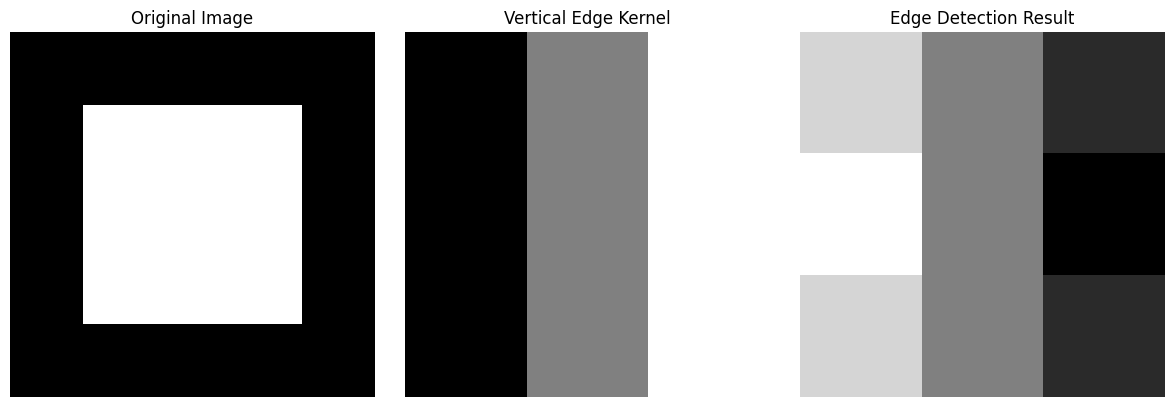


🎉 你亲手完成了第一次「机器视觉」操作！
   神经网络学习的本质，就是学习这些「特征提取」的卷积核权重。


In [4]:
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 原图
axes[0].imshow(image.numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('原始图像')
axes[0].axis('off')

# 卷积核
axes[1].imshow(kernel.numpy(), cmap='gray', vmin=-1, vmax=1)
axes[1].set_title('垂直边缘卷积核')
axes[1].axis('off')

# 边缘检测结果
axes[2].imshow(feature_map.numpy(), cmap='gray')
axes[2].set_title('边缘检测结果')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('images/cnn_day01_edge_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🎉 你亲手完成了第一次「机器视觉」操作！")
print("   神经网络学习的本质，就是学习这些「特征提取」的卷积核权重。")

---

## 5. 更复杂的边缘检测核

经典的 Sobel 边缘检测核可以检测不同方向的边缘：

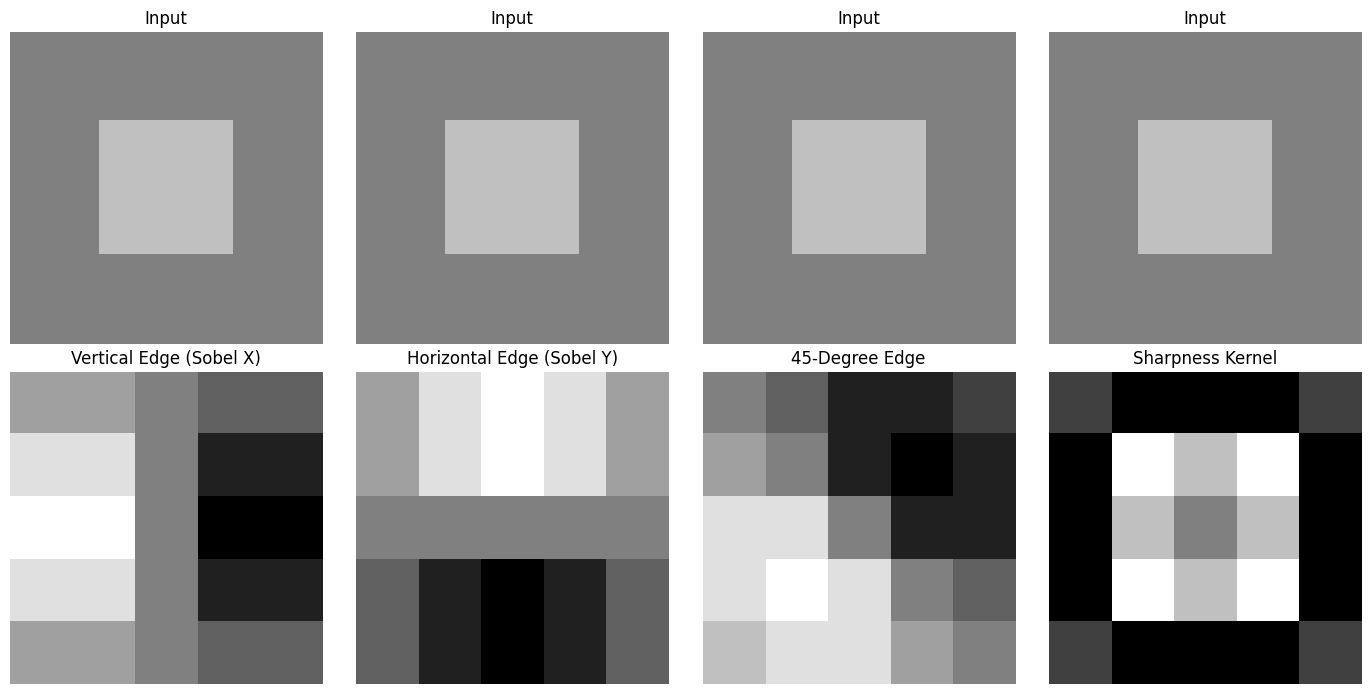


不同卷积核检测不同类型的特征：
  Vertical Edge: 检测垂直边缘
  Horizontal Edge: 检测水平边缘
  45-Degree Edge: 检测对角线
  Sharpness: 增强边缘，让图像更清晰


In [5]:
import torch
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

# 定义多种卷积核
kernels = {
    '垂直边缘 (Sobel X)': torch.tensor([
        [-1.0, 0.0, 1.0],
        [-2.0, 0.0, 2.0],
        [-1.0, 0.0, 1.0]
    ]),
    '水平边缘 (Sobel Y)': torch.tensor([
        [-1.0, -2.0, -1.0],
        [ 0.0,  0.0,  0.0],
        [ 1.0,  2.0,  1.0]
    ]),
    '45度边缘': torch.tensor([
        [ 0.0,  1.0,  2.0],
        [-1.0,  0.0,  1.0],
        [-2.0, -1.0,  0.0]
    ]),
    '锐化卷积核': torch.tensor([
        [ 0.0, -1.0,  0.0],
        [-1.0,  5.0, -1.0],
        [ 0.0, -1.0,  0.0]
    ])
}

# 创建一个更复杂的测试图片
test_image = torch.zeros(7, 7)
test_image[2:5, 2:5] = 1.0  # 一个白色方块在中间

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for idx, (name, k) in enumerate(kernels.items()):
    result = manual_conv2d(test_image, k)
    
    # 原图
    axes[0, idx].imshow(test_image.numpy(), cmap='gray', vmin=-2, vmax=2)
    axes[0, idx].set_title('输入')
    axes[0, idx].axis('off')
    
    # 结果
    axes[1, idx].imshow(result.numpy(), cmap='gray')
    axes[1, idx].set_title(name)
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig('images/cnn_day01_multiple_kernels.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n不同卷积核检测不同类型的特征：")
print("  Vertical Edge: 检测垂直边缘")
print("  Horizontal Edge: 检测水平边缘")
print("  45-Degree Edge: 检测对角线")
print("  Sharpness: 增强边缘，让图像更清晰")

---

## 翻译词典

| 生活直觉 | 深度学习术语 |
|----------|-------------|
| 用手在图像上滑动找边缘 | 卷积运算（Convolution） |
| 一个固定的「模板」 | 卷积核（Kernel） |
| 所有人用同一把尺子量 | 权值共享（Weight Sharing） |
| 只看一小块区域 | 局部感受野（Receptive Field） |
| Sobel 算子 = 边缘检测模板 | 边缘检测卷积核 |


---

## 今日总结

| 概念 | 直觉理解 |
|------|----------|
| 卷积核 (Kernel) | 一个「滑动的小窗口」，像你的手指在纸上滑动 |
| 局部感受野 | 每次只看一小片区域，而不是整张图片 |
| 特征图 (Feature Map) | 卷积核扫过后的输出，记录「哪里有特征」 |
| 权值共享 | 同一个卷积核在整个图片上共享使用，就像用同一把尺子测量 |

**卷积的优势**：
- **参数少**：一个 3x3 卷积核只有 9 个参数，不管图片多大
- **平移不变**：猫在左上角和右下角，都能被同一特征检测到
- **层次化特征**：浅层检测边缘，深层检测更复杂的形状

**明日预告**：今天我们手动定义了卷积核。明天学习如何让神经网络**自己学习**这些卷积核——这就是「卷积层」的作用。